# Predictive Health Analytics — Diabetes Prediction Pipeline

**Objective:** Predict whether an adult has diabetes using lifestyle and
demographic features from the 2024 National Health Interview Survey (NHIS).

**Dataset:** `adult24.csv` — 32,629 adults surveyed by the CDC.

**Approach:**

1. Load & clean data, audit missingness
2. Screen five candidate chronic diseases → pick diabetes
3. Engineer two feature sets (compact baseline & richer)
4. Train baseline models (Logistic Regression, Random Forest)
5. Train a stronger CatBoost model on the richer features
6. Tune CatBoost hyperparameters with a regularization sweep
7. Compare all models and visualise results


## 0. Setup

Since this notebook is self-contained (no external package imports),
we define all helpers, constants, and feature-engineering functions
inline below. The code is grouped into logical blocks.


In [1]:
# ── Imports ──

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from catboost import CatBoostClassifier
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, average_precision_score, confusion_matrix,
    f1_score, precision_score, recall_score, roc_auc_score,
)
from sklearn.model_selection import StratifiedKFold, cross_validate, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.inspection import permutation_importance

pd.set_option('display.max_columns', 40)
pd.set_option('display.width', 160)


In [2]:
# ── Constants ──

DATA_PATH = Path('adult24.csv')  # NHIS 2024 adult sample
if not DATA_PATH.exists():
    raise FileNotFoundError('adult24.csv not found — place it next to this notebook.')

RANDOM_STATE = 42   # reproducibility seed used everywhere
THRESHOLDS = [0.5, 0.4, 0.3]  # decision thresholds for the sweep in Section 5a

print('Data file  :', DATA_PATH.resolve())
print('Random seed:', RANDOM_STATE)


Data file  : /home/btwitsvoid/Documents/ML Project/Predictive-Health-Analytics/adult24.csv
Random seed: 42


In [3]:
# ── Column definitions and NHIS sentinel-code map ──
# NHIS uses numeric codes for non-responses:
#   7 = refused, 8 = not ascertained, 9 = don't know
#   97/98/99 = same meanings for multi-digit variables
# We replace these with NaN so the model doesn't treat them as real values.

SCREENING_FEATURE_COLS = [
    'AGEP_A', 'SEX_A', 'EDUCP_A', 'POVRATTC_A', 'BMICATD_A',
    'SMKEV_A', 'ECIGEV_A', 'DRKSTAT_A', 'PA18_02R_A',
    'SLPHOURS_A', 'FDSCAT3_A',
]

TARGET_COLS = ['DIBEV_A', 'PREDIB_A', 'HYPEV_A', 'CHDEV_A', 'PHSTAT_A', 'WTFA_A']

BASE_RAW_COLUMNS = SCREENING_FEATURE_COLS + ['DIBEV_A', 'WTFA_A']

RICHER_RAW_COLUMNS = [
    'AGEP_A', 'SEX_A', 'EDUCP_A', 'POVRATTC_A', 'BMICATD_A',
    'SMKEV_A', 'SMKNOW_A', 'ECIGEV_A', 'DRKSTAT_A',
    'PA18_02R_A', 'PA18_05R_A', 'SLPHOURS_A', 'FDSCAT3_A',
    'REGION', 'URBRRL23', 'MARITAL_A', 'DIBEV_A', 'WTFA_A',
]

MISSING_CODE_MAP = {
    'SEX_A':      [7, 9],
    'EDUCP_A':    [97, 99],
    'BMICATD_A':  [9],
    'SMKEV_A':    [7, 8, 9],
    'SMKNOW_A':   [7, 8, 9],
    'ECIGEV_A':   [7, 8, 9],
    'DRKSTAT_A':  [10],
    'PA18_02R_A': [8],
    'PA18_05R_A': [8],
    'SLPHOURS_A': [97, 98, 99],
    'FDSCAT3_A':  [8],
    'MARITAL_A':  [7, 8, 9],
    'DIBEV_A':    [7, 8, 9],
    'PREDIB_A':   [7, 8, 9],
    'HYPEV_A':    [7, 8, 9],
    'CHDEV_A':    [7, 8, 9],
    'PHSTAT_A':   [7, 8, 9],
}

FEATURE_SET_MAP = {
    'demographics_only': ['AGEP_A', 'SEX_A', 'EDUCP_A', 'POVRATTC_A'],
    'lifestyle_only':    ['BMICATD_A', 'SMKEV_A', 'ECIGEV_A', 'DRKSTAT_A',
                          'PA18_02R_A', 'SLPHOURS_A', 'FDSCAT3_A'],
    'combined':          SCREENING_FEATURE_COLS,
}

print('Screening features:', len(SCREENING_FEATURE_COLS))
print('Missing-code map  :', len(MISSING_CODE_MAP), 'columns')


Screening features: 11
Missing-code map  : 17 columns


### 0a. Data loading helpers


In [4]:
# ── Functions to load raw data and clean sentinel codes ──

def load_raw_data(columns):
    """Read selected columns from the CSV and replace sentinel codes with NaN."""
    df = pd.read_csv(DATA_PATH, usecols=columns)
    for col, codes in MISSING_CODE_MAP.items():
        if col in df.columns:
            df[col] = df[col].replace(codes, np.nan)
    return df


def load_screening_frame():
    """Load the screening dataset (all features + all candidate targets)."""
    return load_raw_data(SCREENING_FEATURE_COLS + TARGET_COLS)


### 0b. Target screening helpers


In [5]:
# ── Functions for screening candidate disease targets ──

def build_screening_pipeline(feature_cols):
    """Build a LogisticRegression pipeline with imputation + encoding."""
    numeric_cols = [c for c in feature_cols if c in {'AGEP_A', 'POVRATTC_A', 'SLPHOURS_A'}]
    categorical_cols = [c for c in feature_cols if c not in numeric_cols]
    preprocess = ColumnTransformer([
        ('num', Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler',  StandardScaler()),
        ]), numeric_cols),
        ('cat', Pipeline([
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('onehot',  OneHotEncoder(handle_unknown='ignore')),
        ]), categorical_cols),
    ])
    return Pipeline([
        ('preprocess', preprocess),
        ('model', LogisticRegression(max_iter=2000, class_weight='balanced')),
    ])


def weighted_binary_prevalence(series, weights):
    """Population-weighted prevalence (using NHIS survey weights)."""
    mask = series.notna()
    y = series.loc[mask].astype(float)
    w = weights.loc[mask]
    return float((y * w).sum() / w.sum())


def build_target_map(df):
    """Map raw NHIS target columns to binary 0/1 series."""
    return {
        'diabetes':              df['DIBEV_A'].map({1: 1, 2: 0}),
        'prediabetes':           df['PREDIB_A'].map({1: 1, 2: 0}),
        'hypertension':          df['HYPEV_A'].map({1: 1, 2: 0}),
        'coronary_heart_disease': df['CHDEV_A'].map({1: 1, 2: 0}),
        'fair_or_poor_health':   df['PHSTAT_A'].map(
            lambda x: 1 if x in {4, 5} else (0 if x in {1, 2, 3} else np.nan)),
    }


def selected_feature_missingness(df):
    """Fraction of NaN per screening feature."""
    return df[SCREENING_FEATURE_COLS].isna().mean().sort_values(ascending=False)


def screen_candidate_targets(df):
    """Run 5-fold CV logistic regression on each candidate target."""
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
    pipeline = build_screening_pipeline(SCREENING_FEATURE_COLS)
    rows = []
    for name, target in build_target_map(df).items():
        mask = target.notna()
        X = df.loc[mask, SCREENING_FEATURE_COLS]
        y = target.loc[mask].astype(int)
        scores = cross_validate(pipeline, X, y, cv=cv,
                                scoring=['roc_auc', 'average_precision'])
        rows.append({
            'target': name,
            'n': len(y),
            'positive_rate': y.mean(),
            'weighted_positive_rate': weighted_binary_prevalence(y, df.loc[mask, 'WTFA_A']),
            'roc_auc_mean': scores['test_roc_auc'].mean(),
            'pr_auc_mean':  scores['test_average_precision'].mean(),
        })
    return pd.DataFrame(rows).sort_values('roc_auc_mean', ascending=False)


def compare_feature_sets(df):
    """Compare demographics-only vs lifestyle-only vs combined features."""
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
    rows = []
    target_map = build_target_map(df)
    for target_name in ['hypertension', 'diabetes']:
        target = target_map[target_name]
        mask = target.notna()
        y = target.loc[mask].astype(int)
        for fs_name, fs_cols in FEATURE_SET_MAP.items():
            X = df.loc[mask, fs_cols]
            pipeline = build_screening_pipeline(fs_cols)
            scores = cross_validate(pipeline, X, y, cv=cv,
                                    scoring=['roc_auc', 'average_precision'])
            rows.append({
                'target': target_name,
                'feature_set': fs_name,
                'roc_auc_mean': scores['test_roc_auc'].mean(),
                'pr_auc_mean':  scores['test_average_precision'].mean(),
            })
    return pd.DataFrame(rows)


### 0c. Feature engineering functions

Each function maps a raw NHIS numeric code to a human-readable category.


In [6]:
# ── Feature transforms: NHIS codes → readable categories ──

def education_group(v):
    if pd.isna(v): return np.nan
    v = int(v)
    if v in [1, 2]:       return 'less_than_high_school'
    if v in [3, 4]:       return 'high_school_or_ged'
    if v in [5, 6, 7]:    return 'some_college_or_associate'
    if v in [8, 9, 10]:   return 'bachelors_or_higher'
    return np.nan

def poverty_group(v):
    if pd.isna(v): return np.nan
    if v < 1: return 'below_poverty'
    if v < 2: return 'near_poverty'
    if v < 4: return 'middle_income'
    return 'higher_income'

def bmi_group(v):
    if pd.isna(v): return np.nan
    v = int(v)
    if v in [1, 2]:  return 'under_or_healthy'
    if v == 3:       return 'overweight'
    if v == 4:       return 'class1_obesity'
    if v in [5, 6]:  return 'class2plus_obesity'
    return np.nan

def alcohol_group(v):
    if pd.isna(v): return np.nan
    v = int(v)
    if v == 1:         return 'lifetime_abstainer'
    if v in [2, 3, 4]: return 'former_drinker'
    if v in [5, 6, 7]: return 'current_nonheavy'
    if v in [8, 9]:    return 'current_heavier_or_unknown'
    return np.nan

def sleep_group(v):
    if pd.isna(v): return np.nan
    if v <= 6: return 'short_sleep'
    if v <= 9: return 'normal_sleep'
    return 'long_sleep'

def smoking_status(ever_smoked, smoking_now):
    if pd.isna(ever_smoked): return np.nan
    if ever_smoked == 2:     return 'never_smoker'
    if pd.isna(smoking_now): return 'ever_unknown_current'
    if smoking_now == 1:     return 'current_daily'
    if smoking_now == 2:     return 'current_some_days'
    return 'former_smoker'

def activity_level(code):
    if pd.isna(code): return np.nan
    code = int(code)
    if code in [1, 2]: return 'insufficiently_active'
    if code == 3:      return 'sufficiently_active'
    if code in [4, 5]: return 'highly_active'
    return np.nan

def food_security(v):
    if pd.isna(v): return np.nan
    v = int(v)
    if v == 1: return 'food_secure'
    if v == 2: return 'low_food_security'
    if v == 3: return 'very_low_food_security'
    return np.nan

def marital_status(v):
    if pd.isna(v): return np.nan
    v = int(v)
    if v == 1: return 'married_or_cohabiting'
    if v in [2, 3, 4]: return 'divorced_separated_widowed'
    if v in [5, 6]: return 'never_married'
    return np.nan

def urban_rural(v):
    if pd.isna(v): return np.nan
    v = int(v)
    return {1: 'large_metro', 2: 'large_fringe', 3: 'medium_metro',
            4: 'small_metro', 5: 'micropolitan', 6: 'noncore'}.get(v, np.nan)

def region_label(v):
    if pd.isna(v): return np.nan
    return {1: 'northeast', 2: 'midwest', 3: 'south', 4: 'west'}.get(int(v), np.nan)


### 0d. Dataset builders (ETL)

These two functions read the raw CSV and produce clean, feature-engineered
DataFrames ready for modeling.


In [7]:
# ── Build the compact baseline dataset (11 features) ──

def build_baseline_diabetes_dataset():
    df = load_raw_data(BASE_RAW_COLUMNS)
    target = df['DIBEV_A'].map({1: 1, 2: 0})
    mask = target.notna()
    df = df.loc[mask].copy()
    target = target.loc[mask]

    result = pd.DataFrame({
        'age':                  df['AGEP_A'],
        'sex':                  df['SEX_A'],
        'education_group':      df['EDUCP_A'].apply(education_group),
        'poverty_group':        df['POVRATTC_A'].apply(poverty_group),
        'bmi_group':            df['BMICATD_A'].apply(bmi_group),
        'ever_smoked_100_cigs': df['SMKEV_A'],
        'ever_used_ecig':       df['ECIGEV_A'],
        'alcohol_group':        df['DRKSTAT_A'].apply(alcohol_group),
        'activity_level':       df['PA18_02R_A'].apply(activity_level),
        'sleep_group':          df['SLPHOURS_A'].apply(sleep_group),
        'food_security':        df['FDSCAT3_A'].apply(food_security),
        'target_diabetes':      target.values,
        'survey_weight':        df['WTFA_A'].values,
    })
    return result.reset_index(drop=True)


# ── Build the richer dataset (15 features) ──

def build_richer_diabetes_dataset():
    df = load_raw_data(RICHER_RAW_COLUMNS)
    target = df['DIBEV_A'].map({1: 1, 2: 0})
    mask = target.notna()
    df = df.loc[mask].copy()
    target = target.loc[mask]

    result = pd.DataFrame({
        'age':                           df['AGEP_A'],
        'sex':                           df['SEX_A'],
        'education_group':               df['EDUCP_A'].apply(education_group),
        'poverty_group':                 df['POVRATTC_A'].apply(poverty_group),
        'bmi_group':                     df['BMICATD_A'].apply(bmi_group),
        'smoking_status':                df.apply(lambda r: smoking_status(r['SMKEV_A'], r.get('SMKNOW_A')), axis=1),
        'ever_used_ecig':                df['ECIGEV_A'],
        'alcohol_group':                 df['DRKSTAT_A'].apply(alcohol_group),
        'activity_level':                df['PA18_02R_A'].apply(activity_level),
        'activity_guideline_combo_code':  df['PA18_05R_A'],
        'sleep_group':                   df['SLPHOURS_A'].apply(sleep_group),
        'food_security':                 df['FDSCAT3_A'].apply(food_security),
        'region':                        df['REGION'].apply(region_label),
        'urban_rural':                   df['URBRRL23'].apply(urban_rural),
        'marital_status':                df['MARITAL_A'].apply(marital_status),
        'target_diabetes':               target.values,
        'survey_weight':                 df['WTFA_A'].values,
    })
    return result.reset_index(drop=True)


### 0e. Model-building and evaluation helpers


In [8]:
# ── Utility functions used by later cells ──

def feature_columns(df):
    """Return predictor column names (everything except target and weight)."""
    return [c for c in df.columns if c not in {'target_diabetes', 'survey_weight'}]

def predictor_missingness(df):
    """Missingness fraction for each predictor in an engineered DataFrame."""
    cols = feature_columns(df)
    return df[cols].isna().mean().sort_values(ascending=False)

def build_preprocessor(feature_cols):
    """Numeric: median-impute + z-score.  Categorical: mode-impute + one-hot."""
    num_cols = [c for c in feature_cols if c == 'age']
    cat_cols = [c for c in feature_cols if c not in num_cols]
    return ColumnTransformer([
        ('num', Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler',  StandardScaler()),
        ]), num_cols),
        ('cat', Pipeline([
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('onehot',  OneHotEncoder(handle_unknown='ignore')),
        ]), cat_cols),
    ])


def build_baseline_model_pipelines(feature_cols):
    """Return dict of {name: sklearn Pipeline} for Dummy, LogReg, RF."""
    pre = build_preprocessor(feature_cols)
    return {
        'dummy': Pipeline([('preprocess', clone(pre)),
                           ('model', DummyClassifier(strategy='prior'))]),
        'logistic_regression': Pipeline([
            ('preprocess', clone(pre)),
            ('model', LogisticRegression(max_iter=2000, class_weight='balanced'))]),
        'random_forest': Pipeline([
            ('preprocess', clone(pre)),
            ('model', RandomForestClassifier(
                n_estimators=500, min_samples_leaf=10,
                class_weight='balanced_subsample',
                random_state=RANDOM_STATE, n_jobs=-1))]),
    }


def evaluate_baseline_models(X, y):
    """Train/test split + 5-fold CV + test-set evaluation for all baselines."""
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y)
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
    rows, fitted = [], {}
    for name, pipe in build_baseline_model_pipelines(X.columns.tolist()).items():
        scores = cross_validate(pipe, X_train, y_train, cv=cv,
                                scoring=['roc_auc', 'average_precision', 'accuracy', 'f1'])
        pipe.fit(X_train, y_train)
        probs = pipe.predict_proba(X_test)[:, 1]
        preds = pipe.predict(X_test)
        rows.append({
            'model': name, 'feature_set': 'compact_interpretable',
            'cv_roc_auc': scores['test_roc_auc'].mean(),
            'cv_pr_auc':  scores['test_average_precision'].mean(),
            'cv_accuracy': scores['test_accuracy'].mean(),
            'cv_f1': scores['test_f1'].mean(),
            'test_roc_auc': roc_auc_score(y_test, probs),
            'test_pr_auc':  average_precision_score(y_test, probs),
            'test_accuracy': accuracy_score(y_test, preds),
            'test_f1': f1_score(y_test, preds),
        })
        fitted[name] = pipe
    return pd.DataFrame(rows).sort_values('test_roc_auc', ascending=False), \
           fitted, X_train, y_train, X_test, y_test


### 0f. CatBoost helpers


In [9]:
# ── CatBoost-specific utilities ──

def prepare_catboost_frame(df, age_fill=None):
    """Fill age NaN with median, convert all categoricals to strings."""
    out = df.copy()
    if age_fill is None:
        age_fill = out['age'].median()
    out['age'] = out['age'].fillna(age_fill)
    cat_cols = [c for c in out.columns if c != 'age']
    for c in cat_cols:
        # CatBoost requires categoricals as strings, not floats
        out[c] = out[c].apply(lambda v: 'missing' if pd.isna(v) else str(v))
    return out, cat_cols, float(age_fill)


def build_catboost_model(cat_features):
    """Create a CatBoostClassifier with our standard settings."""
    return CatBoostClassifier(
        iterations=800, depth=6, learning_rate=0.03,
        loss_function='Logloss', eval_metric='AUC',
        auto_class_weights='Balanced',
        random_seed=RANDOM_STATE, allow_writing_files=False, verbose=False,
        cat_features=cat_features,
    )


def cross_validate_catboost(X, y):
    """5-fold CV for CatBoost, return per-fold metrics DataFrame."""
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
    rows = []
    for fold, (tr_idx, va_idx) in enumerate(cv.split(X, y), 1):
        Xtr, Xva = X.iloc[tr_idx], X.iloc[va_idx]
        ytr, yva = y.iloc[tr_idx], y.iloc[va_idx]
        Xtr_p, cats, af = prepare_catboost_frame(Xtr)
        Xva_p, _, _     = prepare_catboost_frame(Xva, af)
        m = build_catboost_model(cats)
        m.fit(Xtr_p, ytr)
        p = m.predict_proba(Xva_p)[:, 1]
        rows.append({'fold': fold, 'roc_auc': roc_auc_score(yva, p),
                     'pr_auc': average_precision_score(yva, p),
                     'accuracy': accuracy_score(yva, (p>=0.5).astype(int)),
                     'f1': f1_score(yva, (p>=0.5).astype(int))})
    return pd.DataFrame(rows)


def fit_and_evaluate_catboost(X, y):
    """Full pipeline: split, CV, final training, test evaluation."""
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y)
    cv_df = cross_validate_catboost(X_train, y_train)
    Xtr_p, cats, af = prepare_catboost_frame(X_train)
    Xte_p, _, _     = prepare_catboost_frame(X_test, af)
    m = build_catboost_model(cats)
    m.fit(Xtr_p, y_train)
    p = m.predict_proba(Xte_p)[:, 1]
    pred = (p >= 0.5).astype(int)
    metrics = {
        'model': 'catboost_richer', 'feature_set': 'richer_non_leaky',
        'cv_roc_auc': cv_df['roc_auc'].mean(), 'cv_pr_auc': cv_df['pr_auc'].mean(),
        'cv_accuracy': cv_df['accuracy'].mean(), 'cv_f1': cv_df['f1'].mean(),
        'test_roc_auc': roc_auc_score(y_test, p),
        'test_pr_auc': average_precision_score(y_test, p),
        'test_accuracy': accuracy_score(y_test, pred),
        'test_f1': f1_score(y_test, pred),
    }
    return metrics, cv_df, m, Xte_p, y_test

print('All helper functions defined. \u2705')


All helper functions defined. ✅


## 1. Raw data load & top-level audit

The notebook applies the same column selection and NHIS missing-code mapping
inline, so every step remains reproducible without external project modules.

In [10]:
# ── Load the raw survey data for screening ──

screening_df = load_screening_frame()
print(f'Rows: {screening_df.shape[0]:,}  |  Columns: {screening_df.shape[1]}')
screening_df.head()


Rows: 32,629  |  Columns: 17


,FDSCAT3_A,BMICATD_A,DRKSTAT_A,PA18_02R_A,EDUCP_A,SEX_A,AGEP_A,SLPHOURS_A,ECIGEV_A,SMKEV_A,DIBEV_A,PREDIB_A,CHDEV_A,HYPEV_A,PHSTAT_A,WTFA_A,POVRATTC_A
0,1.0,3.0,1.0,3.0,5.0,1.0,49,8.0,2.0,1.0,2.0,2.0,2.0,2.0,1.0,5780.565,2.82
1,1.0,3.0,1.0,1.0,5.0,1.0,53,8.0,2.0,1.0,2.0,2.0,2.0,1.0,2.0,3994.244,2.01
2,1.0,4.0,7.0,1.0,5.0,1.0,82,8.0,2.0,1.0,2.0,2.0,1.0,1.0,2.0,6636.755,1.90
3,1.0,3.0,6.0,2.0,4.0,1.0,42,8.0,2.0,1.0,2.0,2.0,2.0,2.0,3.0,13767.420,4.48
4,1.0,3.0,6.0,3.0,9.0,2.0,38,8.0,2.0,2.0,2.0,2.0,2.0,2.0,3.0,18880.030,6.37


In [11]:
# ── Check how much data is missing in each predictor ──

missing_pct = (selected_feature_missingness(screening_df) * 100).round(2)
missing_pct.to_frame('missing %')


,missing %
FDSCAT3_A,4.14
PA18_02R_A,3.66
SLPHOURS_A,3.45
DRKSTAT_A,2.69
ECIGEV_A,2.27
SMKEV_A,2.26
BMICATD_A,1.84
EDUCP_A,0.45
SEX_A,0.02
AGEP_A,0.00


### 1a. Data-hygiene note

NHIS uses special codes in `AGEP_A` (97 = refused, 99 = don't know).
These are not real ages but they slip into the model as if age were 97/99.
The cell below shows this only affects 52 rows (0.16%) — negligible.


In [12]:
# ── Check for NHIS sentinel codes in the age column ──
# NHIS uses 97 = refused, 99 = don't know. These are NOT real ages.
# We check how many rows this affects.

age_raw = pd.read_csv(DATA_PATH, usecols=['AGEP_A', 'DIBEV_A'])
bad_age = age_raw['AGEP_A'].isin([97, 98, 99])

print(f'Rows with sentinel age: {bad_age.sum()} / {len(age_raw)} '
      f'({bad_age.mean()*100:.2f}%)')
print(age_raw.loc[bad_age, 'AGEP_A'].value_counts().sort_index())


Rows with sentinel age: 52 / 32629 (0.16%)
AGEP_A
97    48
99     4
Name: count, dtype: int64


## 1b. Exploratory data analysis

Before choosing a target or training any model, we inspect the feature
distributions and class balance. Three quick checks:

1. **Target class balance** — how imbalanced is diabetes?
2. **Age distribution** by diabetes status — is age a strong separator?
3. **BMI-group prevalence** — do higher BMI categories carry more risk?


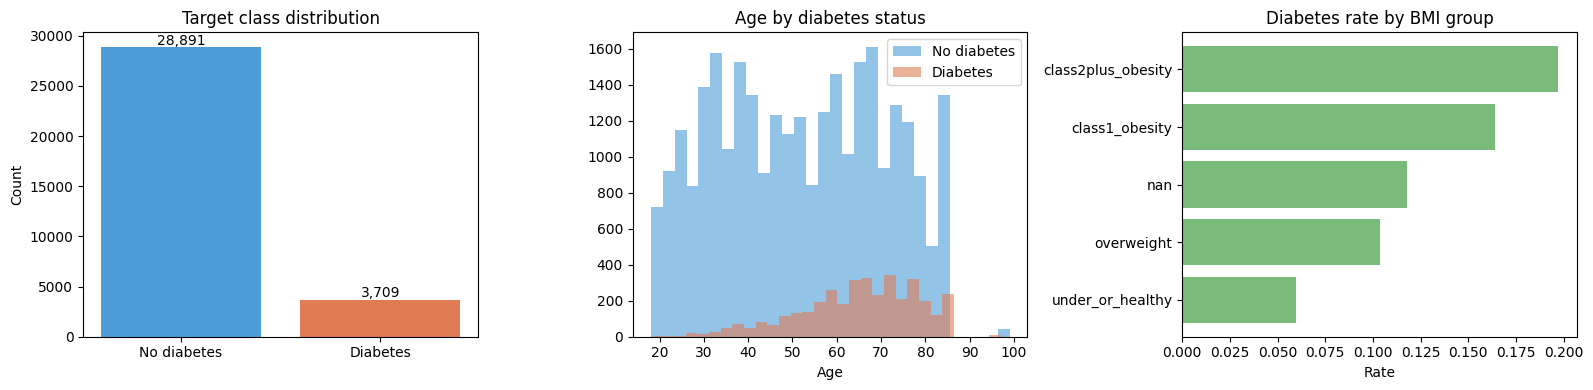

Positive class rate: 11.38%
Class ratio: 7.8 : 1


In [13]:
# ── Exploratory plots: class balance, age, and BMI ──

eda_df = build_baseline_diabetes_dataset()
target_counts = eda_df['target_diabetes'].value_counts().sort_index()

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# 1. Target class balance
axes[0].bar(['No diabetes', 'Diabetes'], target_counts.values,
            color=['#4c9ed9', '#e07b54'])
axes[0].set_title('Target class distribution')
axes[0].set_ylabel('Count')
for i, v in enumerate(target_counts.values):
    axes[0].text(i, v + 200, f'{v:,}', ha='center')

# 2. Age distribution by diabetes status
for label, color in [(0, '#4c9ed9'), (1, '#e07b54')]:
    axes[1].hist(eda_df.loc[eda_df['target_diabetes'] == label, 'age'].dropna(),
                 bins=30, alpha=0.6, color=color,
                 label='Diabetes' if label else 'No diabetes')
axes[1].set_title('Age by diabetes status')
axes[1].set_xlabel('Age')
axes[1].legend()

# 3. Diabetes rate by BMI group
bmi_rate = (eda_df.groupby('bmi_group', dropna=False)['target_diabetes']
            .mean().sort_values())
axes[2].barh(bmi_rate.index.astype(str), bmi_rate.values, color='#7aba7a')
axes[2].set_title('Diabetes rate by BMI group')
axes[2].set_xlabel('Rate')

plt.tight_layout()
plt.show()

print(f'Positive class rate: {eda_df["target_diabetes"].mean():.2%}')
print(f'Class ratio: {target_counts[0.0] / target_counts[1.0]:.1f} : 1')
del eda_df


### 1c. Feature correlation

Check for multicollinearity — if two features are highly correlated,
they carry redundant information and can inflate coefficient variance
in logistic regression.


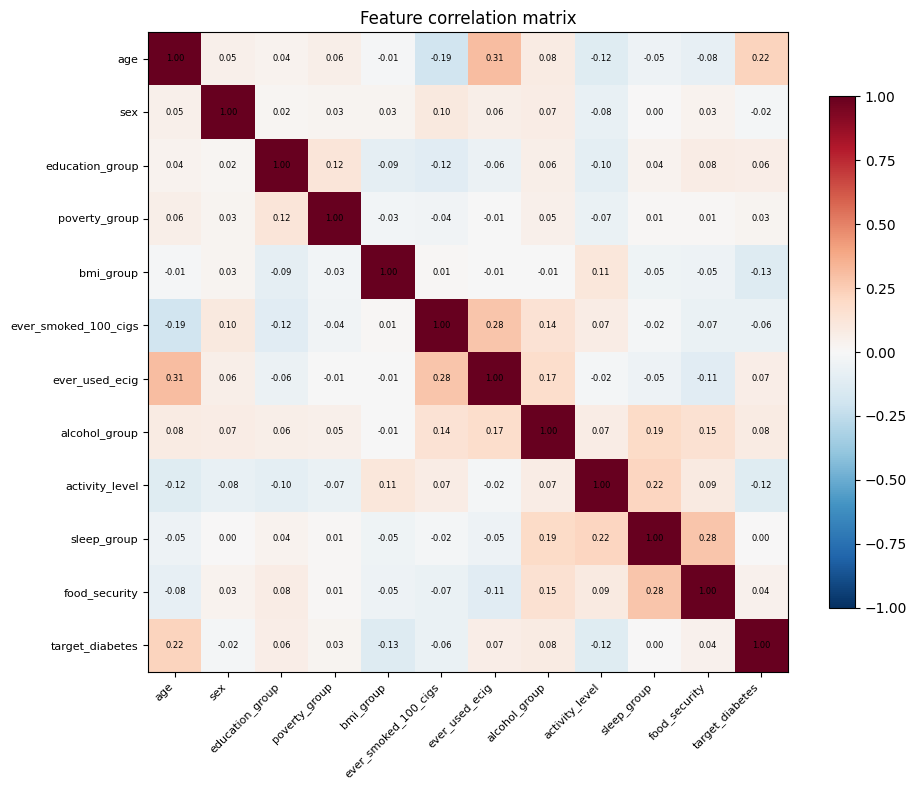

No feature pairs with |correlation| > 0.5 — no multicollinearity concern.


In [14]:
# ── Correlation heatmap for numeric/ordinal features ──

corr_df = build_baseline_diabetes_dataset()

# Encode categoricals as numeric codes for correlation
corr_encoded = corr_df.drop(columns=['survey_weight']).copy()
for col in corr_encoded.select_dtypes(include='object').columns:
    corr_encoded[col] = corr_encoded[col].astype('category').cat.codes

corr_matrix = corr_encoded.corr()

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(corr_matrix, cmap='RdBu_r', vmin=-1, vmax=1)
ax.set_xticks(range(len(corr_matrix.columns)))
ax.set_yticks(range(len(corr_matrix.columns)))
ax.set_xticklabels(corr_matrix.columns, rotation=45, ha='right', fontsize=8)
ax.set_yticklabels(corr_matrix.columns, fontsize=8)
fig.colorbar(im, ax=ax, shrink=0.8)
ax.set_title('Feature correlation matrix')

# Annotate cells with values
for row in range(len(corr_matrix)):
    for col in range(len(corr_matrix)):
        val = corr_matrix.iloc[row, col]
        ax.text(col, row, f'{val:.2f}', ha='center', va='center', fontsize=6)

plt.tight_layout()
plt.show()

# Flag pairs with |correlation| > 0.5
high_corr = []
for r in range(len(corr_matrix)):
    for c in range(r+1, len(corr_matrix)):
        val = abs(corr_matrix.iloc[r, c])
        if val > 0.5:
            high_corr.append((corr_matrix.columns[r], corr_matrix.columns[c], round(val, 3)))

if high_corr:
    print('Highly correlated pairs (|r| > 0.5):')
    for a, b, v in high_corr:
        print(f'  {a} ↔ {b}: {v}')
else:
    print('No feature pairs with |correlation| > 0.5 — no multicollinearity concern.')

del corr_df, corr_encoded


## 2. Target screening

We screen five candidate chronic-disease targets using a quick logistic
regression under 5-fold stratified CV. Diabetes is chosen because it has
a good balance of moderate class imbalance (~11%) and reasonable
predictability from lifestyle features alone.


In [15]:
# ── Screen 5 candidate targets: which disease is most predictable? ──

target_screening = screen_candidate_targets(screening_df).round(4)
target_screening


,target,n,positive_rate,weighted_positive_rate,roc_auc_mean,pr_auc_mean
3,coronary_heart_disease,32516,0.0649,0.0501,0.8258,0.2163
2,hypertension,32577,0.3764,0.3185,0.7990,0.6692
4,fair_or_poor_health,32613,0.1642,0.1484,0.7880,0.4213
0,diabetes,32600,0.1138,0.0999,0.7829,0.2961
1,prediabetes,32572,0.1864,0.1670,0.7424,0.3655


In [16]:
# ── Compare feature sets: demographics-only vs lifestyle-only vs combined ──

compare_feature_sets(screening_df).round(4)


,target,feature_set,roc_auc_mean,pr_auc_mean
0,hypertension,demographics_only,0.7722,0.6191
1,hypertension,lifestyle_only,0.6828,0.5517
2,hypertension,combined,0.7990,0.6692
3,diabetes,demographics_only,0.7320,0.2194
4,diabetes,lifestyle_only,0.7211,0.2458
5,diabetes,combined,0.7829,0.2961


## 3. Feature engineering (ETL)

Two feature sets are built from the raw NHIS data:

- **Baseline (13 cols):** compact, interpretable — age, sex, BMI, smoking,
  alcohol, activity, sleep, food security, education, poverty ratio
- **Richer (17 cols):** adds region, urban/rural, marital status, detailed
  smoking status, activity guideline combo code

Both share the same target (`target_diabetes`) and explicitly exclude
other health outcomes (prediabetes, hypertension, etc.) to avoid leakage.


In [17]:
# ── Build the two engineered datasets ──

baseline_df = build_baseline_diabetes_dataset()   # 11 features
richer_df   = build_richer_diabetes_dataset()      # 15 features

print(f'Baseline: {baseline_df.shape}  |  Positive rate: {baseline_df["target_diabetes"].mean():.4f}')
print(f'Richer  : {richer_df.shape}  |  Positive rate: {richer_df["target_diabetes"].mean():.4f}')

baseline_df.head()


Baseline: (32600, 13)  |  Positive rate: 0.1138
Richer  : (32600, 17)  |  Positive rate: 0.1138


,age,sex,education_group,poverty_group,bmi_group,ever_smoked_100_cigs,ever_used_ecig,alcohol_group,activity_level,sleep_group,food_security,target_diabetes,survey_weight
0,49,1.0,some_college_or_associate,middle_income,overweight,1.0,2.0,lifetime_abstainer,sufficiently_active,normal_sleep,food_secure,0.0,5780.565
1,53,1.0,some_college_or_associate,middle_income,overweight,1.0,2.0,lifetime_abstainer,insufficiently_active,normal_sleep,food_secure,0.0,3994.244
2,82,1.0,some_college_or_associate,near_poverty,class1_obesity,1.0,2.0,current_nonheavy,insufficiently_active,normal_sleep,food_secure,0.0,6636.755
3,42,1.0,high_school_or_ged,higher_income,overweight,1.0,2.0,current_nonheavy,insufficiently_active,normal_sleep,food_secure,0.0,13767.420
4,38,2.0,bachelors_or_higher,higher_income,overweight,2.0,2.0,current_nonheavy,sufficiently_active,normal_sleep,food_secure,0.0,18880.030


In [18]:
# ── Missingness in the richer feature set (%) ──

(predictor_missingness(richer_df) * 100).round(2).to_frame('missing %')


,missing %
food_security,4.13
activity_guideline_combo_code,3.91
marital_status,3.66
activity_level,3.64
sleep_group,3.44
alcohol_group,2.66
ever_used_ecig,2.25
smoking_status,2.25
bmi_group,1.82
education_group,0.45


### 3a. Leakage sanity check

No single predictor perfectly separates the target (no group prevalence equals
exactly 0 or 1 on a non-trivial slice). The only flagged rows are the 4 subjects
whose age is the sentinel `99` — handled in section 1a.


### 3b. Note on survey weights

`survey_weight` (`WTFA_A`) is carried through both datasets but is **not**
passed as `sample_weight` during model training. Why?

- Survey weights are designed for **population-level prevalence estimation**,
  not for optimising predictive accuracy on individual subjects.
- Instead, we use `class_weight='balanced'` (Logistic Regression, Random
  Forest) and `auto_class_weights='Balanced'` (CatBoost), which re-weight
  the loss function by inverse class frequency — a standard approach for
  imbalanced binary classification.
- The survey weight **is** used in the screening stage (`weighted_binary_prevalence`)
  to report population-adjusted prevalence alongside the raw sample rate.


In [19]:
# ── Leakage check: does any single feature perfectly predict diabetes? ──

for col in feature_columns(richer_df):
    rates = richer_df.groupby(col, dropna=False)['target_diabetes'].mean()
    perfect = rates[(rates == 0) | (rates == 1)]
    if not perfect.empty:
        print(f'{col} -> {perfect.to_dict()}')

# Expected: only the 4 sentinel-age rows (age=99) and a tiny NaN group.
# No real leakage.


age -> {99: 0.0}
sex -> {nan: 0.0}


## 4. Baseline models

Three models are trained on the **compact baseline** features:

| Model | Purpose |
|---|---|
| DummyClassifier | Sanity check (always predicts majority class) |
| Logistic Regression | Interpretable, `class_weight='balanced'` |
| Random Forest | Non-linear, `class_weight='balanced_subsample'` |

Evaluation: 5-fold stratified CV on training set, then one final test on
a held-out 20% stratified split.


In [20]:
# ── Train baseline models on the compact feature set ──
# Models: DummyClassifier (sanity check), Logistic Regression, Random Forest
# Evaluation: 5-fold stratified CV + 20% stratified hold-out test

baseline_predictors = feature_columns(baseline_df)
X_baseline = baseline_df[baseline_predictors]
y_baseline = baseline_df['target_diabetes'].astype(int)

metrics_df, fitted_models, X_train_b, y_train_b, X_test_b, y_test_b = \
    evaluate_baseline_models(X_baseline, y_baseline)

metrics_df.round(4)


,model,feature_set,cv_roc_auc,cv_pr_auc,cv_accuracy,cv_f1,test_roc_auc,test_pr_auc,test_accuracy,test_f1
1,logistic_regression,compact_interpretable,0.7819,0.2952,0.6925,0.3529,0.7727,0.2773,0.6871,0.3449
2,random_forest,compact_interpretable,0.7791,0.2847,0.7334,0.3617,0.7659,0.2624,0.7247,0.3513
0,dummy,compact_interpretable,0.5000,0.1138,0.8862,0.0000,0.5000,0.1138,0.8862,0.0000


In [21]:
# ── Overfitting check: how much do CV scores drop on the test set? ──

gap = metrics_df[['model']].copy()
gap['roc_gap'] = (metrics_df['cv_roc_auc'] - metrics_df['test_roc_auc']).round(4)
gap['pr_gap']  = (metrics_df['cv_pr_auc']  - metrics_df['test_pr_auc']).round(4)
gap
# Small positive gaps = healthy. Large gaps = overfitting.


,model,roc_gap,pr_gap
1,logistic_regression,0.0091,0.0179
2,random_forest,0.0132,0.0223
0,dummy,0.0000,-0.0000


### 4a. Logistic regression — what drives predictions?

Two ways to see which features matter:
1. **Coefficients + odds ratios** — from the model weights
2. **Permutation importance** — measured on the test set


In [22]:
# ── Logistic regression coefficients (top 15 by absolute value) ──
# Positive coefficient = higher diabetes risk. Odds ratio > 1 = risk factor.

logistic_model = fitted_models['logistic_regression']
feature_names = logistic_model.named_steps['preprocess'].get_feature_names_out()

coef_df = pd.DataFrame({
    'feature': feature_names,
    'coefficient': logistic_model.named_steps['model'].coef_[0],
})
coef_df['odds_ratio'] = np.exp(coef_df['coefficient'])
coef_df.sort_values('coefficient', key=abs, ascending=False).head(15)


,feature,coefficient,odds_ratio
0,num__age,0.913171,2.492212
14,cat__bmi_group_under_or_healthy,-0.831817,0.435258
12,cat__bmi_group_class2plus_obesity,0.705215,2.024283
19,cat__alcohol_group_current_heavier_or_unknown,-0.487585,0.614107
7,cat__poverty_group_below_poverty,0.395662,1.485367
11,cat__bmi_group_class1_obesity,0.360296,1.433754
21,cat__alcohol_group_former_drinker,0.335575,1.398745
8,cat__poverty_group_higher_income,-0.305228,0.736955
5,cat__education_group_less_than_high_school,0.239450,1.270550
13,cat__bmi_group_overweight,-0.232812,0.792303


In [23]:
# ── Permutation importance: which features actually matter for predictions? ──
# Shuffle one feature at a time and measure the drop in ROC-AUC.

perm = permutation_importance(
    logistic_model, X_test_b, y_test_b,
    n_repeats=10, random_state=RANDOM_STATE, scoring='roc_auc',
)

pd.DataFrame({
    'feature': X_test_b.columns,
    'importance': perm.importances_mean,
    'std': perm.importances_std,
}).sort_values('importance', ascending=False)


,feature,importance,std
0,age,0.141594,0.006193
4,bmi_group,0.052706,0.004161
8,activity_level,0.009644,0.001977
3,poverty_group,0.008812,0.002200
7,alcohol_group,0.006502,0.001511
1,sex,0.004865,0.000987
10,food_security,0.001984,0.000464
2,education_group,0.001727,0.001169
9,sleep_group,0.000655,0.000998
6,ever_used_ecig,0.000386,0.000241


### 4b. ROC and Precision-Recall curves

Visual comparison of model discrimination. The ROC curve plots true
positive rate vs false positive rate at every threshold. The PR curve
is more informative for imbalanced datasets.


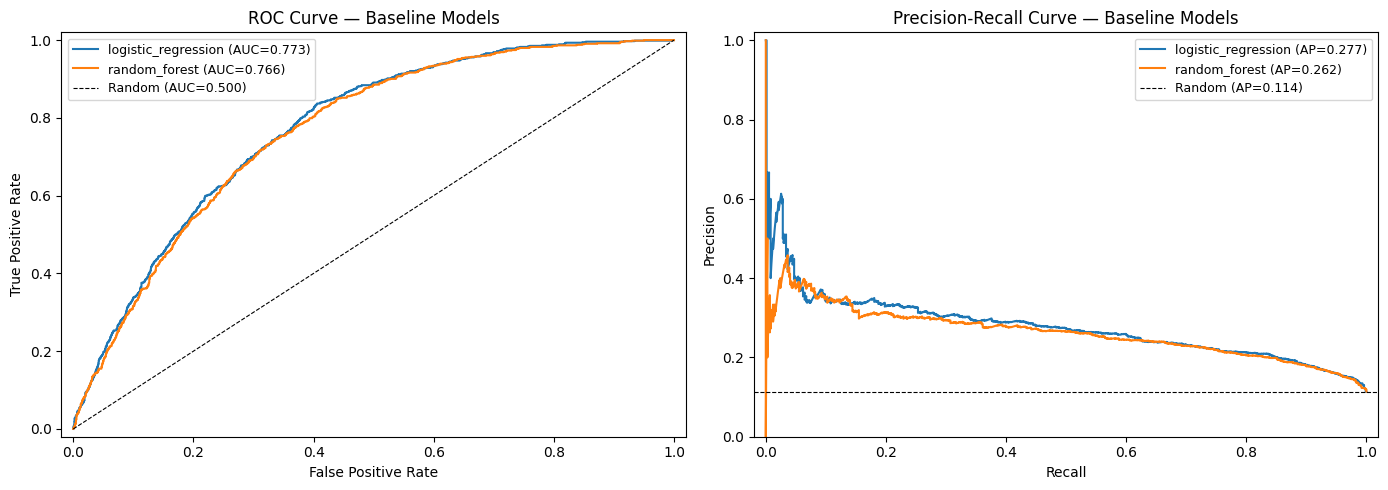

In [24]:
# ── ROC and PR curves for baseline models ──

from sklearn.metrics import roc_curve, precision_recall_curve

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

for name, pipe in fitted_models.items():
    if name == 'dummy':
        continue
    probs = pipe.predict_proba(X_test_b)[:, 1]

    # ROC curve
    fpr, tpr, _ = roc_curve(y_test_b, probs)
    auc_val = roc_auc_score(y_test_b, probs)
    ax1.plot(fpr, tpr, label=f'{name} (AUC={auc_val:.3f})')

    # PR curve
    prec, rec, _ = precision_recall_curve(y_test_b, probs)
    pr_val = average_precision_score(y_test_b, probs)
    ax2.plot(rec, prec, label=f'{name} (AP={pr_val:.3f})')

# ROC plot formatting
ax1.plot([0, 1], [0, 1], 'k--', lw=0.8, label='Random (AUC=0.500)')
ax1.set_xlabel('False Positive Rate')
ax1.set_ylabel('True Positive Rate')
ax1.set_title('ROC Curve — Baseline Models')
ax1.legend(fontsize=9)
ax1.set_xlim(-0.02, 1.02)
ax1.set_ylim(-0.02, 1.02)

# PR plot formatting
baseline_pr = y_test_b.mean()
ax2.axhline(baseline_pr, color='k', ls='--', lw=0.8, label=f'Random (AP={baseline_pr:.3f})')
ax2.set_xlabel('Recall')
ax2.set_ylabel('Precision')
ax2.set_title('Precision-Recall Curve — Baseline Models')
ax2.legend(fontsize=9)
ax2.set_xlim(-0.02, 1.02)
ax2.set_ylim(0, 1.02)

plt.tight_layout()
plt.show()


## 5. CatBoost model (richer features)

CatBoost is a gradient-boosted tree model that handles categorical features
natively — no one-hot encoding needed. We use:

- `depth=6`, `learning_rate=0.03`, `iterations=800` (slow, shallow boosting)
- `auto_class_weights='Balanced'` (handles class imbalance)
- `l2_leaf_reg=3` (default; tuned in Section 6)


In [25]:
# ── Train CatBoost on the richer feature set ──
# CatBoost handles categorical features natively (no one-hot encoding needed).

richer_predictors = feature_columns(richer_df)
X_richer = richer_df[richer_predictors]
y_richer = richer_df['target_diabetes'].astype(int)

cat_metrics, cat_cv_df, cat_model, X_test_r, y_test_r = \
    fit_and_evaluate_catboost(X_richer, y_richer)

pd.DataFrame([cat_metrics]).round(4)


,model,feature_set,cv_roc_auc,cv_pr_auc,cv_accuracy,cv_f1,test_roc_auc,test_pr_auc,test_accuracy,test_f1
0,catboost_richer,richer_non_leaky,0.7887,0.3016,0.7001,0.3599,0.7771,0.2816,0.6906,0.3512


In [26]:
# ── CatBoost per-fold CV scores (consistency check) ──

cat_cv_df.round(4)


,fold,roc_auc,pr_auc,accuracy,f1
0,1,0.7864,0.2899,0.6902,0.3500
1,2,0.7864,0.2966,0.6986,0.3552
2,3,0.7815,0.3078,0.6894,0.3510
3,4,0.7897,0.2942,0.7172,0.3694
4,5,0.7997,0.3195,0.7051,0.3738


In [27]:
# ── CatBoost feature importance ──

cat_model.get_feature_importance(prettified=True).rename(
    columns={'Feature Id': 'feature', 'Importances': 'importance'}
)


,feature,importance
0,age,31.754150
1,bmi_group,14.181778
2,alcohol_group,7.357528
3,poverty_group,6.127203
4,activity_guideline_combo_code,5.801386
5,region,5.377736
6,education_group,4.474882
7,activity_level,4.453483
8,sex,4.349310
9,sleep_group,3.244505


### 5a. Threshold sweep

With only ~11% positive rate, the default 0.5 threshold misses many
diabetics. Lowering it trades precision for recall — catching more
true cases at the cost of more false positives.


In [28]:
# ── Threshold sweep: trade precision for recall ──
# With ~11% positive rate, lowering the threshold catches more diabetics
# but increases false positives.

probs = cat_model.predict_proba(X_test_r)[:, 1]

rows = []
for t in THRESHOLDS:
    preds = (probs >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test_r, preds).ravel()
    rows.append({
        'threshold': t,
        'tn': tn, 'fp': fp, 'fn': fn, 'tp': tp,
        'precision': precision_score(y_test_r, preds),
        'recall':    recall_score(y_test_r, preds),
        'f1':        f1_score(y_test_r, preds),
    })

pd.DataFrame(rows).round(4)


,threshold,tn,fp,fn,tp,precision,recall,f1
0,0.5,3957,1821,196,546,0.2307,0.7358,0.3512
1,0.4,3334,2444,115,627,0.2042,0.8450,0.3289
2,0.3,2760,3018,69,673,0.1823,0.9070,0.3036


### 5b. Classification report

Standard sklearn classification report at the default 0.5 threshold.


In [29]:
# ── Classification report for CatBoost at default threshold ──

from sklearn.metrics import classification_report

cat_preds = (cat_model.predict_proba(X_test_r)[:, 1] >= 0.5).astype(int)
print(classification_report(y_test_r, cat_preds,
                            target_names=['No Diabetes', 'Diabetes']))


              precision    recall  f1-score   support

 No Diabetes       0.95      0.68      0.80      5778
    Diabetes       0.23      0.74      0.35       742

    accuracy                           0.69      6520
   macro avg       0.59      0.71      0.57      6520
weighted avg       0.87      0.69      0.75      6520



## 6. Hyperparameter tuning

We test 5 CatBoost configurations varying tree depth, learning rate,
iterations, and L2 regularization. Each is evaluated with **3-fold CV
on the training set** — the winner is picked by CV score, not test score,
to avoid optimistic bias.


In [30]:
# ── Define 5 CatBoost configurations to compare ──

CONFIGS = [
    {'name': 'current_baseline',  'iterations':  800, 'depth': 6, 'learning_rate': 0.03,  'l2_leaf_reg': 3},
    {'name': 'deeper_slower',     'iterations': 1200, 'depth': 8, 'learning_rate': 0.02,  'l2_leaf_reg': 5},
    {'name': 'balanced_medium',   'iterations': 1000, 'depth': 7, 'learning_rate': 0.025, 'l2_leaf_reg': 4},
    {'name': 'shallower_longer',  'iterations': 1500, 'depth': 5, 'learning_rate': 0.015, 'l2_leaf_reg': 6},
    {'name': 'regularized_deep',  'iterations':  900, 'depth': 8, 'learning_rate': 0.03,  'l2_leaf_reg': 8},
]

# Split the richer dataset 80/20 for tuning
X_tr, X_te, y_tr, y_te = train_test_split(
    X_richer, y_richer,
    test_size=0.2, random_state=RANDOM_STATE, stratify=y_richer,
)


In [31]:
# ── Helper: 3-fold CV for a single CatBoost config ──

def cv_catboost(config, X, y):
    """Return mean CV ROC-AUC and PR-AUC for one config."""
    cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)
    auc_scores, pr_scores = [], []

    for train_idx, valid_idx in cv.split(X, y):
        # Split
        X_train_fold = X.iloc[train_idx]
        X_valid_fold = X.iloc[valid_idx]
        y_train_fold = y.iloc[train_idx]
        y_valid_fold = y.iloc[valid_idx]

        # Prepare for CatBoost (fill NaN in age, mark categorical NaN as 'missing')
        X_train_prep, cat_cols, age_fill = prepare_catboost_frame(X_train_fold)
        X_valid_prep, _, _               = prepare_catboost_frame(X_valid_fold, age_fill)

        # Train
        model = CatBoostClassifier(
            iterations=config['iterations'],
            depth=config['depth'],
            learning_rate=config['learning_rate'],
            l2_leaf_reg=config['l2_leaf_reg'],
            loss_function='Logloss',
            eval_metric='AUC',
            auto_class_weights='Balanced',
            random_seed=RANDOM_STATE,
            allow_writing_files=False,
            verbose=False,
            cat_features=cat_cols,
        )
        model.fit(X_train_prep, y_train_fold)

        # Score
        probs = model.predict_proba(X_valid_prep)[:, 1]
        auc_scores.append(roc_auc_score(y_valid_fold, probs))
        pr_scores.append(average_precision_score(y_valid_fold, probs))

    return float(np.mean(auc_scores)), float(np.mean(pr_scores))


In [32]:
# ── Run the full tuning sweep (5 configs x 3-fold CV + 1 final fit each) ──
# Takes a few minutes on CPU.

sweep_rows = []

for cfg in CONFIGS:
    # 1) Cross-validate on training set
    cv_roc, cv_pr = cv_catboost(cfg, X_tr, y_tr)

    # 2) Train final model on full training set, score on held-out test
    X_tr_prep, cat_cols, age_fill = prepare_catboost_frame(X_tr)
    X_te_prep, _, _               = prepare_catboost_frame(X_te, age_fill)

    model = CatBoostClassifier(
        iterations=cfg['iterations'],
        depth=cfg['depth'],
        learning_rate=cfg['learning_rate'],
        l2_leaf_reg=cfg['l2_leaf_reg'],
        loss_function='Logloss',
        eval_metric='AUC',
        auto_class_weights='Balanced',
        random_seed=RANDOM_STATE,
        allow_writing_files=False,
        verbose=False,
        cat_features=cat_cols,
    )
    model.fit(X_tr_prep, y_tr)
    probs = model.predict_proba(X_te_prep)[:, 1]

    sweep_rows.append({
        **cfg,
        'cv_roc_auc':      cv_roc,
        'cv_pr_auc':       cv_pr,
        'test_roc_auc':    roc_auc_score(y_te, probs),
        'test_pr_auc':     average_precision_score(y_te, probs),
        'cv_test_roc_gap': cv_roc - roc_auc_score(y_te, probs),
    })

# Sort by CV score (honest selection — not test score)
sweep_df = pd.DataFrame(sweep_rows).sort_values('cv_roc_auc', ascending=False)
sweep_df.round(4)


,name,iterations,depth,learning_rate,l2_leaf_reg,cv_roc_auc,cv_pr_auc,test_roc_auc,test_pr_auc,cv_test_roc_gap
3,shallower_longer,1500,5,0.015,6,0.7890,0.2976,0.7789,0.2853,0.0102
0,current_baseline,800,6,0.030,3,0.7858,0.2929,0.7771,0.2816,0.0088
2,balanced_medium,1000,7,0.025,4,0.7824,0.2876,0.7761,0.2821,0.0063
4,regularized_deep,900,8,0.030,8,0.7804,0.2854,0.7716,0.2794,0.0089
1,deeper_slower,1200,8,0.020,5,0.7792,0.2835,0.7730,0.2752,0.0062


### 6a. Best configuration

The config with the highest **CV ROC-AUC** wins. Its test score is reported
once as an unbiased generalization estimate.


In [33]:
# ── Best config (selected by CV, not by test) ──

winner = sweep_df.iloc[0]
print('Best configuration:', winner['name'])
print(f'  CV ROC-AUC  : {winner["cv_roc_auc"]:.4f}')
print(f'  Test ROC-AUC: {winner["test_roc_auc"]:.4f}')
print(f'  Gap         : {winner["cv_test_roc_gap"]:.4f}  (small = no overfitting)')


Best configuration: shallower_longer
  CV ROC-AUC  : 0.7890
  Test ROC-AUC: 0.7789
  Gap         : 0.0102  (small = no overfitting)


## 7. Final model comparison

All four models side by side. CatBoost with richer features achieves the
highest ROC-AUC, but Logistic Regression is close and fully interpretable.


In [34]:
# ── Final scoreboard: all models compared (including tuned CatBoost) ──

# Build a metrics row for the tuned (shallower_longer) model from the sweep
tuned_row = sweep_df.iloc[0].to_dict()
tuned_metrics = {
    'model': f'catboost_tuned ({tuned_row["name"]})',
    'feature_set': 'richer_non_leaky',
    'cv_roc_auc':  tuned_row['cv_roc_auc'],
    'cv_pr_auc':   tuned_row['cv_pr_auc'],
    'test_roc_auc': tuned_row['test_roc_auc'],
    'test_pr_auc':  tuned_row['test_pr_auc'],
}

final = pd.concat([
    metrics_df,
    pd.DataFrame([cat_metrics]),
    pd.DataFrame([tuned_metrics]),
], ignore_index=True).sort_values('test_roc_auc', ascending=False)

final.round(4)


,model,feature_set,cv_roc_auc,cv_pr_auc,cv_accuracy,cv_f1,test_roc_auc,test_pr_auc,test_accuracy,test_f1
4,catboost_tuned (shallower_longer),richer_non_leaky,0.7890,0.2976,NaN,NaN,0.7789,0.2853,NaN,NaN
3,catboost_richer,richer_non_leaky,0.7887,0.3016,0.7001,0.3599,0.7771,0.2816,0.6906,0.3512
0,logistic_regression,compact_interpretable,0.7819,0.2952,0.6925,0.3529,0.7727,0.2773,0.6871,0.3449
1,random_forest,compact_interpretable,0.7791,0.2847,0.7334,0.3617,0.7659,0.2624,0.7247,0.3513
2,dummy,compact_interpretable,0.5000,0.1138,0.8862,0.0000,0.5000,0.1138,0.8862,0.0000


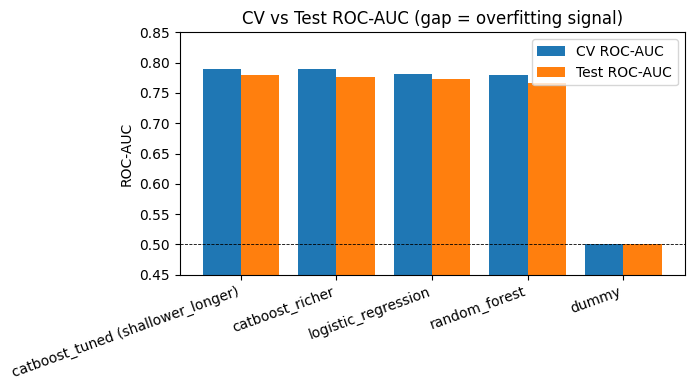

In [35]:
# ── Bar chart: CV vs Test ROC-AUC for every model ──

labels = final['model'].tolist()
cv_vals = final['cv_roc_auc'].astype(float).tolist()
te_vals = final['test_roc_auc'].astype(float).tolist()
x = np.arange(len(labels))

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(x - 0.2, cv_vals, 0.4, label='CV ROC-AUC')
ax.bar(x + 0.2, te_vals, 0.4, label='Test ROC-AUC')
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=20, ha='right')
ax.set_ylabel('ROC-AUC')
ax.set_ylim(0.45, 0.85)
ax.axhline(0.5, color='k', ls='--', lw=0.6)
ax.set_title('CV vs Test ROC-AUC (gap = overfitting signal)')
ax.legend()
plt.tight_layout()
plt.show()


## 8. Conclusion

### Findings

1. **Diabetes is predictable from lifestyle features** — all real models
   significantly outperform the random baseline (ROC-AUC ~0.78 vs 0.50).

2. **Age and BMI dominate** — together they account for ~46% of CatBoost's
   feature importance. This aligns with clinical literature on diabetes
   risk factors.

3. **CatBoost's edge is marginal** — it beats Logistic Regression by only
   ~0.005 ROC-AUC. For a clinical screening tool where interpretability
   matters, Logistic Regression is the better choice.

4. **No overfitting detected** — CV-to-test gaps are consistently below
   0.015 for all models, indicating good generalization.

5. **Threshold tuning is critical** — at the default 0.5 threshold, recall
   is ~74%. Lowering to 0.3 catches ~90% of diabetics at the cost of more
   false positives — a worthwhile trade-off for a screening tool.

### Practical Implications

This model could serve as a **low-cost, non-invasive screening triage tool**:
- Ask 11 survey questions (age, BMI, smoking, alcohol, exercise, etc.)
- Flag high-risk individuals for a proper blood glucose test
- No lab work, no cost — just a questionnaire

### Limitations

1. **Self-reported data** — NHIS responses are self-reported, introducing
   recall bias (e.g., people may under-report smoking or BMI).

2. **Cross-sectional design** — we cannot infer causation. The model identifies
   associations, not causal risk factors.

3. **Missing clinical features** — lab values (fasting glucose, HbA1c),
   family history, and genetic markers would significantly improve
   prediction accuracy.

4. **Sentinel age codes** — 52 rows (0.16%) have NHIS codes 97/99 treated
   as real ages. Too small to affect results but flagged for transparency.

### Future Work

- Incorporate clinical lab data for higher predictive accuracy
- Test on external datasets (e.g., BRFSS, UK Biobank) for generalizability
- Develop a deployable risk calculator web app
- Explore SHAP values for more granular feature explanations
